In [1]:
!pip install -q transformers datasets peft accelerate bitsandbytes trl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 53.9 MB/s eta 0:00:00


In [2]:
import torch
import gc
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_from_disk


In [3]:
# Elimina variables del entrenamiento anterior si existen
for var in ["model", "trainer", "tokenizer"]:
    if var in dir():
        exec(f"del {var}")

gc.collect()
torch.cuda.empty_cache()
print(f"🧹 VRAM libre: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")


🧹 VRAM libre: 41.96 GB


In [7]:
from google.colab import files
import shutil

# Opción A: Subir desde tu máquina local
print("📁 Sube train.jsonl y val.jsonl")
uploaded = files.upload()

# Opción B: Si ya los tienes en Drive del paso anterior, comenta lo de arriba y usa:
 #shutil.copy(f"{DRIVE_BASE}/data/train.jsonl", "/content/train.jsonl")
 #shutil.copy(f"{DRIVE_BASE}/data/val.jsonl", "/content/val.jsonl")

📁 Sube train.jsonl y val.jsonl


Saving train.jsonl to train.jsonl
Saving val.jsonl to val.jsonl


In [8]:
from datasets import load_dataset

dataset = load_dataset("json", data_files={
    "train": "/content/train.jsonl",
    "val":   "/content/val.jsonl"
})

print(f"✅ Train: {len(dataset['train'])} ejemplos")
print(f"✅ Val:   {len(dataset['val'])} ejemplos")
print(f"📋 Columnas: {dataset['train'].column_names}")
print(f"📋 Ejemplo:\n{dataset['train'][0]}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

✅ Train: 10147 ejemplos
✅ Val:   1791 ejemplos
📋 Columnas: ['instruction', 'input', 'output']
📋 Ejemplo:
{'instruction': 'Summarize the revenue performance described in the following SEC filing excerpt.', 'input': "s moving beyond 2D screens toward immersive experiences like augmented and virtual reality to help build the metaverse, which we believe is the next evolution in social technology.\nWe report financial results for two segments: Family of Apps (FoA) and Reality Labs (RL). For FoA, we generate substantially all of our revenue from selling advertising placements to marketers. Ads on our platforms enable marketers to reach people based on a variety of factors including age, gender, location, interests, and behaviors. Marketers purchase ads that can appear in multiple places including on Facebook, Instagram, Messenger, and third-party applications and websites. RL generates revenue from sales of consumer hardware products, software and content. Our products include: \nFamily of A

In [9]:
from huggingface_hub import login
login()  # Ingresa tu token de HuggingFace

In [10]:
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"
MAX_SEQ_LEN = 1024
OUTPUT_DIR = "/content/drive/MyDrive/llama3_qlora_output"  # Carpeta distinta al LoRA


In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token  # NO agregar tokens nuevos
tokenizer.padding_side = "right"

print(f"✅ pad_token_id: {tokenizer.pad_token_id}")
print(f"✅ eos_token_id: {tokenizer.eos_token_id}")


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

✅ pad_token_id: 128009
✅ eos_token_id: 128009


In [12]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                       # Carga en 4-bit
    bnb_4bit_quant_type="nf4",               # NormalFloat4 (mejor para LLMs)
    bnb_4bit_compute_dtype=torch.bfloat16,   # Cómputo en BF16 para estabilidad
    bnb_4bit_use_double_quant=True,          # Doble cuantización (ahorra más VRAM)
)

print("✅ BitsAndBytesConfig listo")


✅ BitsAndBytesConfig listo


In [14]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
      # Más rápido en A100
)

model.config.use_cache = False  # Necesario para gradient checkpointing
model = prepare_model_for_kbit_training(model)  # Prepara capas para entrenamiento en 4-bit

print(f"✅ Modelo cargado en 4-bit")
print(f"   VRAM usada: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ Modelo cargado en 4-bit
   VRAM usada: 3.03 GB


In [15]:
lora_config = LoraConfig(
    r=16,                          # Mismo rank que usaste en LoRA
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Esperado: ~0.5-1% de parámetros entrenables


trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


In [18]:
MAX_SEQ_LEN = 1024

SYSTEM_PROMPT = (
    "You are a senior financial analyst assistant specialized in SEC filings. "
    "Answer accurately and concisely based on the provided context from 10-K and 10-Q reports."
)

def format_prompt(example):
    """Aplica el chat template de Llama-3.2-Instruct."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": example["instruction"]},
        {"role": "assistant", "content": example["output"]},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

# Aplicar formato
formatted = dataset.map(format_prompt, remove_columns=dataset["train"].column_names)

print(f"✅ Ejemplo formateado:\n{formatted['train'][0]['text'][:500]}...")


Map:   0%|          | 0/10147 [00:00<?, ? examples/s]

Map:   0%|          | 0/1791 [00:00<?, ? examples/s]

✅ Ejemplo formateado:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 21 Aug 2026

You are a senior financial analyst assistant specialized in SEC filings. Answer accurately and concisely based on the provided context from 10-K and 10-Q reports.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize the revenue performance described in the following SEC filing excerpt.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<|eot_id|>...


In [19]:

def tokenize_fn(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding="max_length",
    )
    labels = []
    for ids in tokens["input_ids"]:
        label = [(t if t != tokenizer.pad_token_id else -100) for t in ids]
        labels.append(label)
    tokens["labels"] = labels
    return tokens

tokenized = formatted.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text"],
    load_from_cache_file=False,  # Forzar re-tokenización
)
tokenized.set_format("torch")

# Verificación
sample = tokenized["train"][0]
n_active = (sample["labels"] != -100).sum().item()
print(f"✅ Tokens activos: {n_active}/{MAX_SEQ_LEN} ({n_active/MAX_SEQ_LEN*100:.1f}%)")
print(f"✅ ¿Labels contienen -100? {(-100 in sample['labels'])}")


Map:   0%|          | 0/10147 [00:00<?, ? examples/s]

Map:   0%|          | 0/1791 [00:00<?, ? examples/s]

✅ Tokens activos: 81/1024 (7.9%)
✅ ¿Labels contienen -100? True


In [20]:
with torch.no_grad():
    batch = {k: v.unsqueeze(0).to(model.device) for k, v in tokenized["train"][0].items()}
    out = model(**batch)
    print(f"✅ Loss inicial: {out.loss.item():.4f}")
    assert not torch.isnan(out.loss), "❌ Loss es NaN, revisa el modelo"
    print("✅ Modelo listo para entrenar")


✅ Loss inicial: 4.4783
✅ Modelo listo para entrenar


In [22]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=50,                      # ✅ Reemplaza warmup_ratio
    weight_decay=0.01,
    fp16=False,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=200,
    save_only_model=True,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    dataloader_pin_memory=False,
)


In [24]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["val"],
    data_collator=data_collator,
)

print("🚀 Iniciando entrenamiento QLoRA...")
trainer.train()


🚀 Iniciando entrenamiento QLoRA...


Step,Training Loss,Validation Loss
50,0.277845,0.166031
100,0.045695,0.043112
150,0.040882,0.039542
200,0.040360,0.039501
250,0.041298,0.038872
300,0.039681,0.039288
350,0.039022,0.038544
400,0.039081,0.039003
450,0.038561,0.038661
500,0.041433,0.038904


TrainOutput(global_step=1905, training_loss=0.07926840082084725, metrics={'train_runtime': 14094.9724, 'train_samples_per_second': 2.16, 'train_steps_per_second': 0.135, 'total_flos': 5.31736335055061e+17, 'train_loss': 0.07926840082084725, 'epoch': 3.0})

In [25]:
ADAPTER_DIR = "/content/drive/MyDrive/llama3_qlora_adapters"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"✅ Adaptadores guardados en: {ADAPTER_DIR}")

# Tamaño de los adaptadores
import os
total = sum(os.path.getsize(os.path.join(ADAPTER_DIR, f)) for f in os.listdir(ADAPTER_DIR))
print(f"📦 Tamaño total: {total / 1e6:.1f} MB")


✅ Adaptadores guardados en: /content/drive/MyDrive/llama3_qlora_adapters
📦 Tamaño total: 114.5 MB


NameError: name 'REPORTS_DIR' is not defined

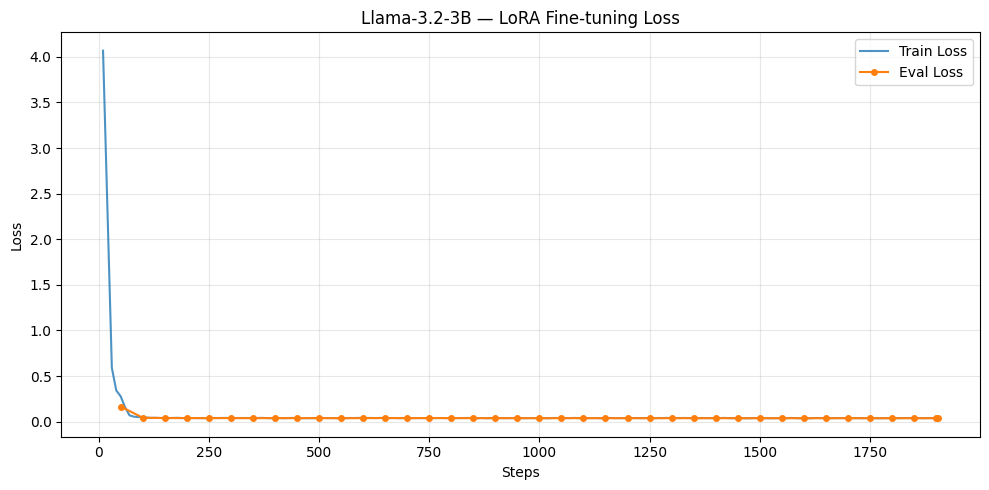

In [28]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss  = [x["loss"] for x in log_history if "loss" in x]

eval_steps = [x["step"] for x in log_history if "eval_loss" in x]
eval_loss  = [x["eval_loss"] for x in log_history if "eval_loss" in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Train Loss", alpha=0.8)
plt.plot(eval_steps, eval_loss, label="Eval Loss", marker="o", markersize=4)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Llama-3.2-3B — LoRA Fine-tuning Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = f"{REPORTS_DIR}/llama3b_lora_loss.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"📊 Gráfica guardada en: {plot_path}")

In [29]:
from peft import PeftModel

# El modelo ya está en memoria con el adaptador, pero si necesitas recargarlo:
# base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")
# model = PeftModel.from_pretrained(base_model, MODEL_OUT)

model.eval()

# ── 4. Preguntas de prueba ──
test_questions = [
    "What are the main risk factors disclosed in a typical 10-K filing?",
    "Summarize the key components of an SEC annual report.",
    "What is the difference between a 10-K and a 10-Q filing?",
]

for q in test_questions:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": q},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=256,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
        )

    response = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    print(f"\n{'='*60}")
    print(f"❓ {q}")
    print(f"💬 {response}")


❓ What are the main risk factors disclosed in a typical 10-K filing?
💬 In a typical 10-K filing, the main risk factors disclosed are identified and described in the "Risk Factors" or "Risk Factors and Discussion of Debt Securities" section. These risk factors may include:

1. **Liquidity risk**: Difficulty in generating cash flow or meeting debt obligations due to factors like debt levels, revenue performance, or operating expenses.
2. **Market risk**: Exposure to market fluctuations in securities markets, interest rates, or foreign exchange rates that could impact revenue, expenses, or cash flow.
3. **Debt obligations**: Risks associated with debt, such as default risk, interest rate risk, or debt restructuring.
4. **Credit risk**: Risks related to the company's creditworthiness, such as potential downgrades or defaults on debt obligations.
5. **Operational risk**: Risks related to the company's internal or external operations, such as system failures, supply chain disruptions, or re